# Midterm 1 practice exam

This is a practice version of Wednesday's exam, not a second copy of it.
Every item below uses the same five formats as the real exam, and mostly the same datasets, but different questions with different numbers.
Memorizing the answers below will not help you on Wednesday, and that is deliberate.

The real exam has five parts: read the code, comment the marked lines, read the result, judge the choice, and what a result rests on.
This practice set has the same five parts, in the same order, worth the same points.
There is no coding-production section here, because the real exam does not have one either.
If you want to practice writing code by hand, that is what the separate review notebook is for.

This assignment is graded on completion, not correctness.
A genuine attempt at every part earns full credit for that part, whether your answer turns out right or wrong.

## Submission instructions

Upload the `ipynb` file to Canvas:
> File -> Download -> ipynb -> upload to Canvas (like any other file)

The `ipynb` file type is the only accepted format.

Save a copy before beginning.
Reloading or disconnecting can revert the notebook to the instructor copy.

# Problem 0 (-10 pts if blank): generative AI usage statement

As you work on this assignment, feel free to use generative AI tools to help you learn,
understand, and debug Python code. In particular, you could get hints or conceptual guidance in
the implementation you write yourself.

However, you must clearly disclose and cite all use of AI. You must include:
1. The name(s) of the AI tool(s) used.
2. The specific prompt(s) you used to generate the content.
3. A description of how you used the output and what edits or additions you made to integrate it
   into your own work.

You are fully responsible for the final submitted work. Critically evaluate, fact-check, and
verify all AI-generated content for validity. Failure to properly cite and disclose AI use
constitutes plagiarism under Penn State's Academic Integrity policy.

Write your disclosure (or "I did not use an AI tool for this assignment") in the cell below.

*your disclosure here*

# Dataset

Wednesday's exam is on paper, with no computer, so this rehearsal reuses data you have already met rather than a new file.
This assignment uses four databases: the NIST corrosion database from Lecture 14, the tetrahedrite thermoelectric database from Lecture 7 and Homework 3, the titanium implant alloy compilation from Lecture 5 and Lecture 12, and the composite mechanical testing file from Lecture 8.
It also reuses the optical constants file from Lecture 9 and the superconductor table from Lecture 11.

> Nothing below is new syntax.
> If a line looks unfamiliar, it is worth finding which lecture it came from before Wednesday.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## The corrosion database, filtered to sulfuric acid

Lecture 14 read the full NIST corrosion database and narrowed it to tests run in sulfuric acid with a numeric rate.
The cell below repeats that same filter so `acid` is ready for the rest of this assignment.

In [2]:
#@title Load the NIST corrosion database (click ▶ to run, data loading, not a learning objective) { display-mode: "form" }
import os

import pandas as pd

_file = 'corrosion.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}',
                 f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    table = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

print(f'Loaded {len(table)} corrosion tests from {_file}')
print(f'  {table["Environment"].nunique()} environments, {table["Material Family"].nunique()} material families')

Loaded 24721 corrosion tests from corrosion.csv
  288 environments, 90 material families


In [3]:
is_sulfuric = table['Environment'].to_numpy() == 'Sulfuric Acid'
has_rate = pd.notna(table['rate_mm_yr_numeric']).to_numpy()
acid = table.loc[is_sulfuric & has_rate]
material = np.array(acid['Material'].tolist())
rate = acid['rate_mm_yr_numeric'].to_numpy()

print(len(acid))

1154


`rate` is the corrosion rate in mm/yr for each of these tests.
`material` names the alloy tested.
`acid['Temperature (deg C)']` names the test temperature, stored as text because a few entries are things like `"200-400"` or `"Boiling"`.

## The tetrahedrite thermoelectric database

Homework 3 and Lecture 7 both used this file: the highest thermoelectric figure of merit, zT, that each tetrahedrite sample reached.
The cell below loads the full table rather than the plain lists Lecture 7 used, because this assignment also needs the dopant used in each sample.

In [4]:
te_url = 'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/thermoelectrics.csv'

te = pd.read_csv(te_url)
te = te.dropna(subset=['zT_max'])

print(len(te))

278


`te['zT_max']` is the highest zT each sample reached, dimensionless, bigger is better.
`te['dopant_family']` names what the tetrahedrite was doped with.
`te['study_id']` names the publication each sample came from.

## The titanium implant alloy compilation

Lecture 5 used this compilation for the spread of yield strengths, and Lecture 12 returned to it to fit tensile strength against yield strength.
`data['DAR_pct']`, used later in this assignment, is the deformation at rupture: how far a specimen stretched before it broke, as a percentage.

In [5]:
#@title Load the Ti-alloy dataset (click ▶ to run, data loading, not a learning objective) { display-mode: "form" }
import os

import pandas as pd


def _find(name):
    return next(
        (p for p in (f'datasets/{name}', f'../datasets/{name}', f'../../datasets/{name}',
                     f'../../../datasets/{name}')
         if os.path.exists(p)),
        f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{name}',
    )


try:
    data = pd.read_csv(_find('biomaterials_ti_alloys.csv'))
except Exception as e:
    raise RuntimeError(
        "Could not load the Ti-alloy data. If you are in Colab, check your "
        "internet connection."
    ) from e

print(f'Loaded {len(data)} titanium alloys')
data[['eid', 'YS_MPa', 'UTS_MPa']].head()

Loaded 283 titanium alloys


,eid,YS_MPa,UTS_MPa
0,Ti-23Nb-10Zr-2.0Fe,782.0,NaN
1,Ti-27Nb-10Zr-1.5Fe,735.0,NaN
2,Ti-31Nb-10Zr-1.0Fe,672.0,NaN
3,Ti-11Nb-7Zr-3.5Fe,1011.0,NaN
4,Ti-19Nb-6Sn-2.5Fe,765.0,NaN


## The superconductor table

Lecture 11 used this table, one row per reported measurement, to compare which superconductors clear the liquid-nitrogen line at 77 K.

In [6]:
#@title Find the three-column superconductor table (click ▶ to run) { display-mode: "form" }
import os

_file = 'superconductors_l11.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (path for path in (
        f'datasets/{_file}',
        f'../datasets/{_file}',
        f'../../datasets/{_file}',
        f'../../../datasets/{_file}',
    ) if os.path.exists(path)),
    None,
)
source = _local if _local else _github

print(f'Ready to read {_file}')

Ready to read superconductors_l11.csv


In [7]:
sc = pd.read_csv(source)

print(len(sc))

21263


## The composite mechanical testing file

Lecture 8 used this file to introduce missing values and mixed-type columns.
`strength_MPa` and `modulus_GPa` are both stored as text in the raw file, because a handful of untested specimens are recorded with a dash instead of a number.

In [8]:
composite_url = 'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/composite_mechanical_testing.csv'
tests = pd.read_csv(composite_url)

print(len(tests))

121


## The optical constants file

Lecture 9 used this file to plot refractive index against wavelength for several materials.

In [9]:
opt_url = 'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/optical_constants.csv'
opt = pd.read_csv(opt_url)

print(len(opt))

47


# Part A: read the code (12 pts, 6 items)

On Wednesday you will read code on paper and write down what it prints, with no computer to check yourself.
Write your prediction for each part below before you run the check cell underneath it.

> Reading the check cell's output first only feels like knowing the answer, and it is not the same thing.

**A1.** What does this print?

```python
radii = np.array([53, 31, 167, 112])
print(radii[1:3])
print(radii[-1])
```

*your answer here*

In [10]:
radii = np.array([53, 31, 167, 112])
print(radii[1:3])
print(radii[-1])

[ 31 167]
112


**A2.** What does this print, or what error does it raise?

```python
record = {'grade': 'A36', 'yield_MPa': 250}
print(record['tensile_MPa'])
```

*your answer here*

In [11]:
# EXPECTED-ERROR: this cell intentionally fails
record = {'grade': 'A36', 'yield_MPa': 250}
print(record['tensile_MPa'])

KeyError: 'tensile_MPa'

**A3.** What does this print?

```python
tc = np.array([29.0, 88.0, 4.2, 92.0])
mask = tc > 77
print(np.sum(mask))
print(tc[mask])
```

*your answer here*

In [12]:
tc = np.array([29.0, 88.0, 4.2, 92.0])
mask = tc > 77
print(np.sum(mask))
print(tc[mask])

2
[88. 92.]


**A4.** What does this print?

```python
sample = np.array(['Heo 2014', 1.13, 302])
print(sample.dtype)
print(sample[1] * 2)
```

> This is not an invented example.
> It is one actual row of `te`: a Mn-doped sample from the Heo 2014 study, with `zT_max` 1.13 and `zT_max_temp_C` 302.

*your answer here*

In [13]:
sample = np.array(['Heo 2014', 1.13, 302])
print(sample.dtype)
print(sample[1] * 2)

<U32
1.131.13


**A5. Fill in the blank.** `temp` holds temperatures parsed from text, with `nan` where the entry could not be parsed as a number (things like `"Boiling"`).
This should mark the entries that came back as ordinary numbers.

```python
has_temp = np.__________(temp)
```

*your answer here*

**A6. Fill in the blank.** `zt` holds thermoelectric zT_max values. This should print the middle value, not the average.

```python
print(np.__________(zt))
```

*your answer here*

# Part B: comment the marked lines (20 pts, 5 lines, 4 points each)

This is the same shape of analysis Lecture 14 ran on the corrosion file, run here on the thermoelectric file instead: define a population, then compute on it.
Beside each marked line, write one sentence saying **what the line does** and **why it is there for this data**.
Unmarked lines are not graded.

study_id                              object
composition                           object
dopant_family                         object
Cu_stoichiometry                     float64
zT_350C                              float64
zT_max                               float64
zT_max_temp_C                        float64
zT_max_temp_K                        float64
seebeck_350C_uVK                     float64
seebeck_at_zTmax_uVK                 float64
conductivity_350C_1e4Sm              float64
conductivity_at_zTmax_1e4Sm          float64
thermal_conductivity_350C_WmK        float64
thermal_conductivity_at_zTmax_WmK    float64
carrier_concentration_cm3            float64
synthesis                             object
compaction                            object
sintering_type                        object
sintering_temp_K                     float64
sintering_temp_C                     float64
relative_density_pct                 float64
density_g_cm3                        float64
theoretica

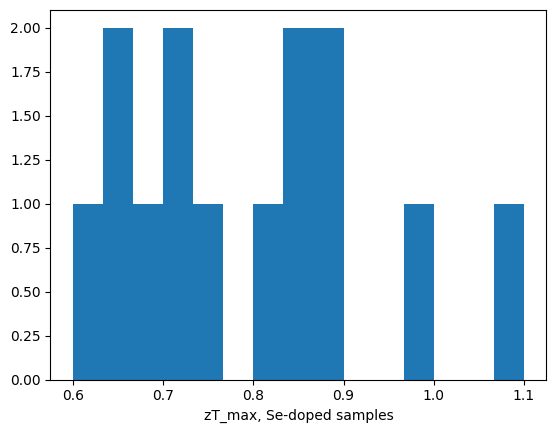

In [14]:
te_raw = pd.read_csv(te_url)
print(te_raw.dtypes)

is_se = te_raw['dopant_family'].to_numpy() == 'Se'                       # B1
has_zt = pd.notna(te_raw['zT_max']).to_numpy()                          # B2

se = te_raw.loc[is_se & has_zt]
print(len(se))                                                          # prints 14

zt = se['zT_max'].to_numpy()
print(f'{np.min(zt):.2f} to {np.max(zt):.2f}')                          # B3

fig, ax = plt.subplots()
ax.hist(zt, bins=15)                                                    # B4
ax.set_xlabel('zT_max, Se-doped samples')

print(f'n={len(zt)}  median {np.median(zt):.2f}')                       # B5

**B1** *your answer here*

**B2** *your answer here*

**B3** *your answer here*

**B4** *your answer here*

**B5** *your answer here*

# Part C: read the result (24 pts, 6 items, 4 points each)

Each answer fits in two or three sentences.

**C1. (4 pts)** Lecture 12 asked you to refit the temperature model on Hastelloy C-276 instead of 304.
Run the cell below to see that fit.

In [15]:
is_c276 = material == 'Hastelloy C-276 Haynes International'
temp = pd.to_numeric(acid['Temperature (deg C)'], errors='coerce').to_numpy()
has_temp = np.isfinite(temp)

mask = is_c276 & has_temp
print(np.sum(mask), 'C-276 tests report both a numeric rate and a temperature')

x_c276 = temp[mask]
y_c276 = np.log10(rate[mask])
fit_c276 = stats.linregress(x_c276, y_c276)
print(f'slope     = {fit_c276.slope:.4f} per degC')
print(f'intercept = {fit_c276.intercept:.3f}')
print(f'r         = {fit_c276.rvalue:.3f}')

29 C-276 tests report both a numeric rate and a temperature
slope     = 0.0010 per degC
intercept = -0.868
r         = 0.097


In one or two sentences, does temperature predict this alloy's corrosion rate the way it predicted 304's rate in Lecture 14?
Point to the number that tells you.

*your answer here*

**C2. (4 pts)** Lecture 12 also left the yield strength versus ductility fit as an exercise.
Run the cell below.

In [16]:
ductile = data.dropna(subset=['YS_MPa', 'DAR_pct'])
print(len(ductile), 'of', len(data), 'alloys report both yield strength and DAR_pct')

x_dar = ductile['YS_MPa']
y_dar = ductile['DAR_pct']
fit_dar = stats.linregress(x_dar, y_dar)
print(f'slope     = {fit_dar.slope:.4f} %/MPa')
print(f'intercept = {fit_dar.intercept:.1f} %')
print(f'r         = {fit_dar.rvalue:.3f}')

254 of 283 alloys report both yield strength and DAR_pct
slope     = -0.0433 %/MPa
intercept = 40.8 %
r         = -0.584


(a) What are the units of the slope? `[                        ]`

(b) What does the sign of the slope say about the relationship between yield strength and how far an alloy stretches before it breaks?

*your answer here*

**C3. (4 pts)** Run the cell below.

In [17]:
print(f"mean:   {np.mean(te['zT_max']):.2f}")
print(f"median: {np.median(te['zT_max']):.2f}")

mean:   0.64
median: 0.66


Here the mean sits below the median, the other way around from the corrosion rates in Lecture 14.
In one or two sentences, which side is the long tail on, and what does that say about the samples at that end?

*your answer here*

**C4. (4 pts)** The C-276 fit from C1 also printed a residual standard deviation and an R².

In [18]:
y_hat = fit_c276.slope * x_c276 + fit_c276.intercept
resid = y_c276 - y_hat
print(f'residual standard deviation: {np.std(resid, ddof=1):.3f} log10 units')
print(f'R^2: {fit_c276.rvalue ** 2:.3f}')

residual standard deviation: 0.575 log10 units
R^2: 0.009


Does this fit support estimating one specific C-276 test's rate from its temperature alone?
In one sentence, say what the residual standard deviation above means for a single test, as a multiplying factor rather than in log10 units.

*your answer here*

**C5. (4 pts)** Run the cell below.

In [19]:
modulus_raw = pd.to_numeric(tests['modulus_GPa'], errors='coerce').to_numpy()
print(np.sum(np.isfinite(modulus_raw)), 'of', len(modulus_raw), 'specimens report a modulus')
print(np.nanmean(modulus_raw))

107 of 121 specimens report a modulus
29.140712149532707


Write the sentence you would put under that number in a report, naming the population it describes.

*your answer here*

**C6. (4 pts)** Run the cell below.

In [20]:
many_elements = sc.loc[sc['number_of_elements'] >= 6]
print(len(many_elements), 'of', len(sc), 'records')
print(f"{np.median(many_elements['critical_temp']):.1f} K")

3515 of 21263 records
64.1 K


Write the caption you would put under that number, naming the population it describes.
Say in a few words why it is not evidence that a superconductor with six or more elements typically works at that temperature in a device.

*your answer here*

# Part D: judge the choice (24 pts, 4 items, 6 points each)

**D1. (6 pts)** The fit in C2 gives `DAR_pct` against `YS_MPa` across 254 titanium alloys, with an R² around 0.34.
A designer picking one alloy for one implant asks how far that specific alloy will stretch before it breaks.
Can they read that off the fitted line?
Say what they should use instead.

*your answer here*

**D2. (6 pts)** The alloys the D1 fit was built on run from 170 to 1880 MPa of yield strength.

In [21]:
pred_2200 = fit_dar.slope * 2200 + fit_dar.intercept
print(pred_2200)

-54.45838982090733


Python did not complain, but the printed number describes a negative percentage of stretch, which cannot happen.
What is the name for what was done to get this number, and why does that name explain why it came out impossible?

*your answer here*

**D3. (6 pts)** Run the cell below.
It reproduces a figure from Lecture 9, with no legend and no color chosen by material.

Text(0, 0.5, 'refractive index n')

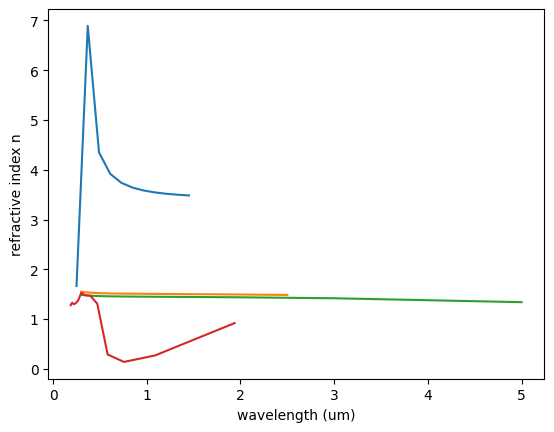

In [22]:
silicon = opt.loc[opt['material'] == 'silicon']
bk7 = opt.loc[opt['material'] == 'BK7']
fused_silica = opt.loc[opt['material'] == 'fused_silica']
gold = opt.loc[opt['material'] == 'gold']

fig, ax = plt.subplots()
ax.plot(silicon['wavelength_um'], silicon['n'])
ax.plot(bk7['wavelength_um'], bk7['n'])
ax.plot(fused_silica['wavelength_um'], fused_silica['n'])
ax.plot(gold['wavelength_um'], gold['n'])
ax.set_xlabel('wavelength (um)')
ax.set_ylabel('refractive index n')

Name one thing a reader cannot do with this figure that they could do if it had a legend and one color per material.

*your answer here*

**D4. (6 pts)** Run the cell below.

In [23]:
one_formula = sc.loc[sc['material'] == 'Cu4Ba2Ca2O8']
print(sorted(one_formula['critical_temp'].tolist(), reverse=True))

[118.0, 110.0, 100.0, 82.0, 78.0, 67.0]


One formula, six rows, six different critical temperatures.
What does that tell you about what one row of this table represents?
What would you need in order to explain the spread?

*your answer here*

# Part E: what it rests on (20 pts)

**E1. (8 pts)** The margin fit in Lecture 12 and Lecture 13 supports this conclusion:

> Across this compilation, tensile strength runs an average of about 194 MPa above yield strength, but any one alloy's own margin runs anywhere from about -45 to over 1250 MPa.

Rests on: *your answer here*

Does not support: *your answer here*

**E2. (8 pts)** Lecture 5 reported this conclusion:

> The mean Young's modulus across this compilation of 237 titanium alloys is about 82 GPa, well below the roughly 110 GPa of the workhorse implant alloy Ti-6Al-4V.

Rests on: *your answer here*

Does not support: *your answer here*

**E3. (4 pts)** Run the cell below.

In [24]:
is_c22 = material == 'Alloy C-22'
is_titanium = material == 'Titanium'

print(f'Alloy C-22: n={np.sum(is_c22)}  median {np.median(rate[is_c22]):.2f} mm/yr')
print(f'Titanium:   n={np.sum(is_titanium)}  median {np.median(rate[is_titanium]):.2f} mm/yr')

Alloy C-22: n=39  median 0.08 mm/yr
Titanium:   n=38  median 0.70 mm/yr


The count was put on the line deliberately.
In one sentence, say what the count is there for, and what you would conclude differently about a median printed beside `n=4`.

*your answer here*

# Wrap-up

This assignment introduced no new syntax.
It rehearsed the five question types Wednesday's exam uses: reading code without running it, filling a blank in a printed line, commenting a marked line with what it does and why it is there for that data, reading a single number or figure, and saying what a result rests on and does not establish.

Every dataset here was already familiar, from a lecture, a homework, or both.
Reusing them here is deliberate: the exam rewards recognizing a pattern you have already practiced, not meeting a new dataset cold.

One page of handwritten notes is allowed on Wednesday.
The note-page list Lecture 14 gave you is still the right list to start from.